In [4]:
import sys
import os

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q
    os.kill(os.getpid(), 9)  # force runtime restart

# Открытые источники данных временных рядов


Любая работа с прогнозированием начинается не с модели, а с вопроса **«на чём учиться и с чем
сравнивать?»**. Пока у вас нет данных, вы не можете ни проверить гипотезу, ни доказать, что ваша
модель лучше чужой. Хорошая новость: сообщество уже собрало десятки тысяч готовых рядов и
выложило их бесплатно. Плохая новость: они лежат в шести разных местах, в пяти разных форматах,
и у каждого свои правила игры.

Этот ноутбук — карта местности. Мы пройдём по пяти главным источникам, разберём, **зачем нужен
каждый**, и для каждого напишем **работающий код загрузки**.

## Что мы разберём

| № | Источник | Чем ценен |
|---|---|---|
| 0 | Обзор: как устроены источники | Понять, что выбирать и почему |
| 1 | [Monash Repository](https://forecastingdata.org/) | Главный академический бенчмарк: ~30 доменов в одном формате |
| 2 | [Kaggle](https://www.kaggle.com/c/rossmann-store-sales/overview) | Сырые «грязные» бизнес-данные с признаками |
| 3 | [M-соревнования (M4)](https://nixtlaverse.nixtla.io/datasetsforecast/m4.html) | 100 000 рядов, эталон для сравнения точности |
| 4 | ETT / Electricity / Traffic / Weather / Exchange | Датасеты из статей про нейросети (long-horizon) |
| 5 | [LOTSA](https://huggingface.co/datasets/Salesforce/lotsa_data) | 27 млрд точек для обучения foundation-моделей |


> **Важно про интернет.** Почти весь ноутбук качает данные из сети. Каждая загрузка кэшируется
> в папку `data/` рядом с ноутбуком, поэтому повторный запуск ячейки идёт мгновенно и уже
> без интернета.

---
# 0. Как устроены источники данных временных рядов

## 0.1. Три типа источников, и зачем нужен каждый


| Тип | Что это | Типичный размер | Зачем берут |
|---|---|---|---|
| **Бенчмарк-архивы** | Monash, M-соревнования | тысячи–сотни тысяч рядов | сравнить свой метод с чужими на равных |
| **Соревнования** | Kaggle | 1 задача, много признаков | научиться работать с сырыми данными |
| **Датасеты из статей** | ETT, Electricity, Traffic | 1–900 рядов, но очень длинных | воспроизвести результаты статьи |

🔍 У многих датасетов есть «канонический» способ деления на train/test — и если вы поделите данные иначе, ваши числа
нельзя будет сопоставить с числами из статей/сорвенований 

## 0.2. Два формата хранения: «широкий» и «длинный»

Один и тот же набор рядов можно записать двумя способами.

**Широкий (wide)** — каждый ряд это отдельный столбец, время в индексе:

```
date         store_1   store_2   store_3
2015-01-01      120       340        55
2015-01-02      135       298        61
```

**Длинный (long / tidy)** — три столбца: «кто», «когда», «сколько»:

```
unique_id     ds          y
store_1       2015-01-01  120
store_1       2015-01-02  135
store_2       2015-01-01  340
```

| | Широкий | Длинный |
|---|---|---|
| Ряды одинаковой длины | обязательно (иначе `NaN`) | не обязательно |
| Удобно смотреть глазами | да | нет |
| Формат `statsmodels` | да (одна серия = один столбец) | нет |
| Формат `statsforecast`, `neuralforecast`, `darts` | нет | **да** |

🔍 **Про длинный формат.** Экосистема Nixtla (`statsforecast`, `neuralforecast`,
`mlforecast`) требует **строго** длинный формат с колонками `unique_id`, `ds`, `y`. Это стало
де-факто стандартом, поэтому в этом ноутбуке мы **любой** источник будем приводить именно
к нему. Так шесть разных источников становятся взаимозаменяемыми: код, написанный для одного,
работает и для остальных.

## 0.3. Как делить временной ряд на train/test

Это тот раздел, из-за которого чаще всего получаются «прекрасные» модели, проваливающиеся в
продакшене. Разберём его до того, как начнём качать данные.

### Главное правило: делим по времени, а не случайно

```python
# ❌ КАТАСТРОФА для временного ряда
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(df, test_size=0.2)   # перемешает даты!

# ✅ Правильно: тест — это всегда «будущее»
test = df.groupby("unique_id").tail(horizon)
train = df.drop(test.index)
```

Почему `train_test_split` здесь смертелен: перемешав строки, вы отдаёте модели **январь 2020 в
обучение, а декабрь 2019 в тест**. Модель «подглядывает в будущее» — это называется **утечкой
данных (data leakage)**. Метрика на валидации получается блестящей, а на реальном прогнозе
модель рассыпается, потому что в жизни будущего в обучающей выборке не бывает.

### Три уровня разбиения

| Часть | Зачем | Как отрезаем |
|---|---|---|
| **train** | обучить параметры модели | самое раннее время |
| **validation** | подобрать гиперпараметры, выбрать модель | следующий кусок |
| **test** | один раз честно измерить качество | самый конец ряда |

Порядок строго хронологический: `train < validation < test`. В long-horizon статьях (раздел 4)
принято 70% / 10% / 20%, для ETT — 60% / 20% / 20%.

### Горизонт (`horizon`) — это не «сколько процентов», а «сколько шагов»

Для временных рядов размер теста задаётся **не долей, а горизонтом прогноза** — числом шагов,
которые вы обязуетесь предсказать. У каждого бенчмарка он свой и зафиксирован:

| Бенчмарк | Горизонт |
|---|---|
| M4 Hourly | 48 (двое суток) |
| M4 Monthly | 18 (полтора года) |
| Monash | указан в метаданных каждого датасета |
| ETT / Electricity / Traffic | 96, 192, 336, 720 |

🔍 **Почему горизонт нельзя выбирать самому.** Прогноз на 1 шаг вперёд и на 720 шагов — это
задачи разной сложности. Сравнивать MAE модели с горизонтом 24 и модели с горизонтом 720
бессмысленно, даже если данные одни и те же. Поэтому в бенчмарках горизонт — часть условия
задачи, а не ваш параметр.

### Одного разбиения обычно мало: rolling origin

Отрезав один тестовый кусок, вы измерили качество **на одном отрезке времени**. Если там
случился ковид или новогодний пик — оценка получится случайной. Поэтому в реальной работе
используют **кросс-валидацию со скользящим началом** (rolling origin / expanding window):

```
окно 1:  [-----train-----][test]
окно 2:  [-------train-------][test]
окно 3:  [---------train---------][test]
```

Обучаемся на всём, что было до момента прогноза, предсказываем следующие `horizon` точек,
сдвигаемся вперёд и повторяем. В `statsforecast` это метод
`.cross_validation(h=..., n_windows=...)`. Обратите внимание: обучающее окно **растёт**, а
тестовое едет вперёд — так имитируется реальная жизнь, где данных со временем становится больше.

### Чек-лист перед обучением

1. Тест — самые поздние точки ряда, а не случайные.
2. Размер теста равен горизонту бенчмарка, если он задан.
3. Все преобразования (нормировка, заполнение пропусков, отбор признаков) считаются
   **только по train** и затем применяются к test. Посчитали среднее по всему датасету —
   получили утечку.
4. Каждый признак должен быть **известен в момент прогноза**. Погода на завтра — сомнительно,
   день недели на завтра — можно.

In [5]:
import gzip
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# plot_series — готовый инструмент из экосистемы Nixtla (пакет utilsforecast,
# который ставится вместе со statsforecast). Он умеет рисовать длинный формат
# как есть, без ручного цикла по рядам.
from utilsforecast.plotting import plot_series

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

# Все загруженные данные складываем в папку data/ рядом с ноутбуком.
# Это важная привычка: библиотеки по умолчанию любят класть кэш в домашний каталог
# (~/.gluonts, ~/.cache), и потом невозможно понять, сколько гигабайт где лежит.
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("pandas:", pd.__version__)
print("numpy: ", np.__version__)
print("данные будут лежать в:", DATA_DIR.resolve())

pandas: 2.3.3
numpy:  2.4.6
данные будут лежать в: /Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_1/part_2/data


### Служебные функции: загрузка с кэшем и сводка по датасету

Часть разделов качает файлы напрямую. Чтобы не писать одно и то же несколько раз, сделаем одну
функцию с **кэшированием**: если файл уже на диске, повторно он качаться не будет.

In [6]:
def download(url: str, filename: str, subdir: str = "raw") -> Path:
    """Скачать файл по URL в data/<subdir>/<filename> и вернуть путь.

    Если файл уже существует, он не перекачивается. Это и есть кэширование:
    первый запуск ячейки идёт через сеть, все последующие — с диска.
    """
    target_dir = DATA_DIR / subdir
    target_dir.mkdir(parents=True, exist_ok=True)
    path = target_dir / filename

    if path.exists() and path.stat().st_size > 0:
        print(f"уже скачано: {path}  ({path.stat().st_size / 1e6:.2f} МБ)")
        return path

    print(f"скачиваю {url} ...")
    # stream=True — чтобы большой файл не загружался целиком в оперативную память.
    with requests.get(url, timeout=180, stream=True) as response:
        response.raise_for_status()  # бросить исключение, если сервер ответил 404/500
        with open(path, "wb") as f:
            for chunk in response.iter_content(chunk_size=1 << 20):  # по 1 МБ
                f.write(chunk)

    print(f"готово: {path}  ({path.stat().st_size / 1e6:.2f} МБ)")
    return path


def describe_long(df: pd.DataFrame, name: str = "датасет"):
    """Короткая сводка по датасету в длинном формате: то, что мы обсуждали в разделе 0."""
    lengths = df.groupby("unique_id", observed=True).size()
    print(f"--- {name} ---")
    print(f"строк всего:        {len(df):,}")
    print(f"рядов (unique_id):  {df['unique_id'].nunique():,}")
    print(
        f"длина ряда:         мин {lengths.min()}, медиана {int(lengths.median())}, "
        f"макс {lengths.max()}"
    )
    if pd.api.types.is_datetime64_any_dtype(df["ds"]):
        print(f"период:             {df['ds'].min()} — {df['ds'].max()}")
    print(f"пропусков в y:      {df['y'].isna().sum():,}")


print("служебные функции готовы")

служебные функции готовы


### Как рисовать длинный формат: `plot_series`

Своя функция рисования нам не нужна — в экосистеме Nixtla уже есть `plot_series` из пакета
`utilsforecast` (устанавливается вместе с `statsforecast`). Она принимает ровно тот длинный
формат, к которому мы приводим все источники.

| Аргумент | Зачем |
|---|---|
| `df` | датафрейм с колонками `unique_id`, `ds`, `y` |
| `ids` | список конкретных рядов, которые рисовать |
| `max_ids` | сколько рядов показать (по умолчанию 8) |
| `plot_random` | `False` — брать первые ряды, а не случайные |
| `max_insample_length` | показать только последние N точек |
| `engine` | `"matplotlib"` или `"plotly"` (интерактивный) |

🔍 **`plot_random=True` — это значение по умолчанию.** Если его не выставить в `False`,
при каждом запуске вы получите разные ряды на графике, и результат ноутбука будет
невоспроизводимым. Для учебных материалов это почти всегда не то, что нужно.

---
# 1. Monash Time Series Forecasting Repository

**Сайт:** https://forecastingdata.org/ · **Статья:** [Godahewa et al., NeurIPS 2021](https://arxiv.org/abs/2105.06643)

## 1.1. Что это и зачем

До 2021 года в области был бардак: каждая статья бралa свои данные, по-своему их делила и
заявляла «мы лучшие». Сравнивать результаты было невозможно. Команда из **университета Монаша**
(Австралия) собрала ~30 датасетов из разных доменов — энергетика, транспорт, продажи, погода,
здравоохранение, финансы — привела их **к одному формату** и посчитала точность десятка
базовых моделей на каждом.


| Плюсы | Минусы |
|---|---|
| ~30 доменов, единый формат | ряды уже «причёсаны», нет сырой грязи |
| Опубликованы результаты baseline-моделей | нет внешних признаков (погода, акции, цены) |
| Указан канонический горизонт прогноза | некоторые датасеты весят гигабайты |

## 1.2. Формат `.tsf` и готовые загрузчики

Monash хранит данные в текстовом формате `.tsf` — авторы предложили его по образцу формата
[`.ts` из `sktime`](https://www.sktime.net/en/stable/examples/datasets/loading_data.html).
Файл выглядит так: сначала «шапка» с метаданными (`@`-строки), потом после `@data` по одной
строке на ряд.

```
@relation Hospital
@frequency monthly
@missing false
@data
T1:2000-01-01 00-00-00:27,16,18,19,21,...
```

🔍 **Почему это удобнее CSV.** Ряды в Monash имеют **разную длину**. В широком CSV пришлось бы
добивать короткие ряды `NaN` до длины самого длинного. Здесь каждая строка ровно такой длины,
какая нужна, а дата хранится только для первой точки: остальные восстанавливаются из
`@frequency`.

**Парсер писать не нужно** — готовых загрузчиков как минимум четыре:

| Загрузчик | Как выглядит вызов |
|---|---|
| **`sktime`** (используем ниже) | `load_forecastingdata("hospital_dataset")` |
| **`gluonts`** | `get_dataset("hospital")` из [`gluonts.dataset.repository`](https://ts.gluon.ai/stable/api/gluonts/gluonts.dataset.repository.html) |
| **Hugging Face** | `load_dataset("`[`Monash-University/monash_tsf`](https://huggingface.co/datasets/Monash-University/monash_tsf)`", "hospital")` |
| **Авторские скрипты** | [`TSForecasting/utils/data_loader.py`](https://github.com/rakshitha123/TSForecasting/blob/master/utils/data_loader.py) — референсная реализация на Python и R |

Возьмём `sktime`: у него самый прямой интерфейс, он сам скачивает нужный `.tsf` и отдаёт
метаданные вместе с данными.

* [`load_forecastingdata`](https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.datasets.load_forecastingdata.html) — функция
* [`ForecastingData`](https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.datasets.forecasting.monash.ForecastingData.html) — класс-обёртка с тем же набором датасетов

In [7]:
from sktime.datasets import load_forecastingdata

# Hospital: 767 месячных рядов с количеством пациентов по медицинским продуктам (2000–2006).
# extract_path — куда распаковать .tsf; иначе sktime положит его внутрь своего пакета.
hospital_raw, hospital_meta = load_forecastingdata(
    "hospital_dataset",
    extract_path=DATA_DIR / "sktime",
)

print("метаданные из шапки .tsf:")
for key, value in hospital_meta.items():
    print(f"  {key:24s} {value}")

print(f"\nтип результата: {type(hospital_raw).__name__}, форма {hospital_raw.shape}")
print(f"колонки: {hospital_raw.columns.tolist()}")

метаданные из шапки .tsf:
  frequency                monthly
  forecast_horizon         None
  contain_missing_values   False
  contain_equal_length     True

тип результата: DataFrame, форма (767, 3)
колонки: ['series_name', 'start_timestamp', 'series_value']


### Формат по умолчанию: одна строка = целый ряд

`sktime` вернул `default_tsf` — представление, максимально близкое к самому файлу: колонка
`series_value` содержит **весь ряд целиком** в виде массива, а не отдельные значения по строкам.

🔍 Аргумент `return_type` умеет отдавать и другие форматы, например `"pd_multiindex_hier"` —
датафрейм с мультииндексом, родной для моделей `sktime`. Нам удобнее разобрать `default_tsf`
вручную: так видно, откуда берётся ось времени.

In [8]:
first = hospital_raw.iloc[0]
print(f"series_name:     {first['series_name']}")
print(f"start_timestamp: {first['start_timestamp']}")
print(
    f"series_value:    массив длиной {len(first['series_value'])}, "
    f"первые 6: {np.asarray(first['series_value'][:6])}"
)

series_name:     T1
start_timestamp: 2000-01-01 00:00:00
series_value:    массив длиной 84, первые 6: [27. 16. 18. 19. 21. 20.]


### Приводим к длинному формату

Ось времени восстанавливаем через `pd.date_range`: знаем дату старта, частоту из метаданных
и количество значений — этого достаточно.

In [9]:
# Словарь Monash -> обозначения частот pandas.
MONASH_FREQ = {
    "yearly": "YS",  # YS = Year Start, начало года
    "quarterly": "QS",
    "monthly": "MS",  # MS = Month Start
    "weekly": "W",
    "daily": "D",
    "hourly": "h",
    "half_hourly": "30min",
    "10_minutes": "10min",
    "minutely": "min",
}


def tsf_to_long(raw: pd.DataFrame, meta: dict) -> pd.DataFrame:
    """Превратить результат load_forecastingdata в длинный формат (unique_id, ds, y)."""
    freq = MONASH_FREQ[meta["frequency"]]
    frames = []
    for row in raw.itertuples(index=False):
        values = np.asarray(row.series_value, dtype="float64")
        frames.append(
            pd.DataFrame(
                {
                    "unique_id": row.series_name,
                    "ds": pd.date_range(row.start_timestamp, periods=len(values), freq=freq),
                    "y": values,
                }
            )
        )
    return pd.concat(frames, ignore_index=True)


hospital_long = tsf_to_long(hospital_raw, hospital_meta)
describe_long(hospital_long, "Monash Hospital")
hospital_long.head()

--- Monash Hospital ---
строк всего:        64,428
рядов (unique_id):  767
длина ряда:         мин 84, медиана 84, макс 84
период:             2000-01-01 00:00:00 — 2006-12-01 00:00:00
пропусков в y:      0


,unique_id,ds,y
0,T1,2000-01-01,27.0
1,T1,2000-02-01,16.0
2,T1,2000-03-01,18.0
3,T1,2000-04-01,19.0
4,T1,2000-05-01,21.0


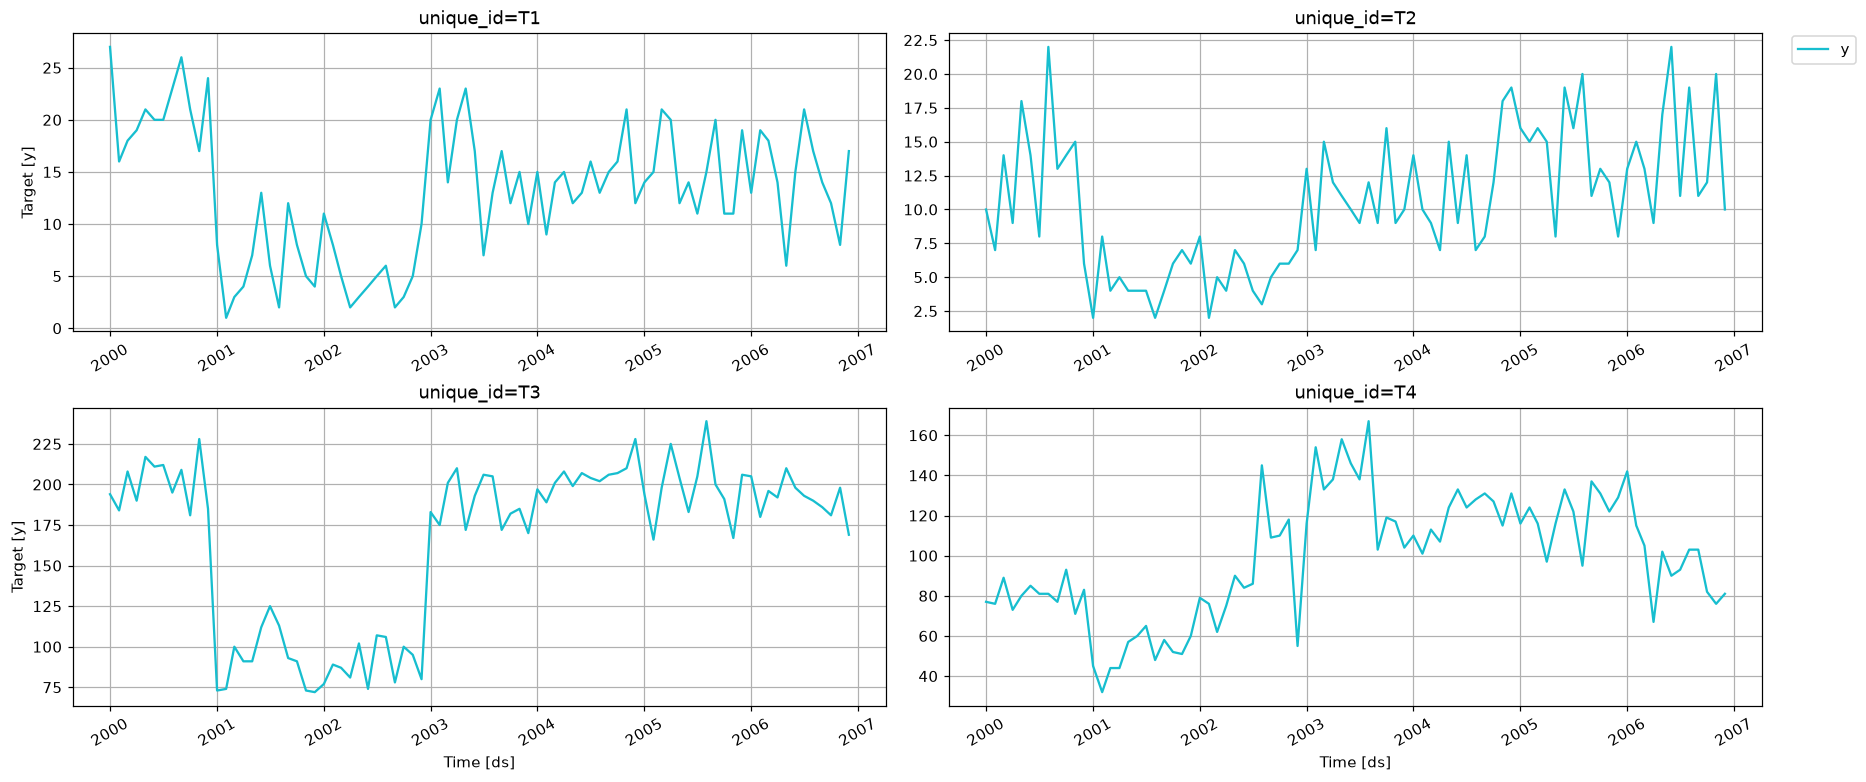

In [10]:
plot_series(
    hospital_long,
    max_ids=4,
    plot_random=False,  # без этого при каждом запуске будут разные ряды
    engine="matplotlib",
)

🔍 **Что видно на графиках.** У рядов есть резкий провал примерно в начале 2001 года. Это не
ошибка загрузки — так выглядят реальные данные: где-то изменилась методика учёта или
классификация продуктов. Такие **структурные сдвиги** (structural breaks) — типичная головная
боль прогнозиста: модель, обученная на данных до сдвига, после него ошибается систематически.

### Другие датасеты Monash через тот же вызов

Имя датасета = имя файла на forecastingdata.org без расширения. Например:

```python
load_forecastingdata("nn5_weekly_dataset")            # 111 недельных рядов, снятие наличных в ATM
load_forecastingdata("traffic_weekly_dataset")        # 862 недельных ряда загруженности дорог
load_forecastingdata("cif_2016_dataset")              # 72 ряда с соревнования CIF 2016
load_forecastingdata("australian_electricity_demand_dataset")  # 5 рядов, получасовая частота
load_forecastingdata("sunspot_dataset_with_missing_values")     # солнечные пятна с пропусками
```

🔍 Обратите внимание на `forecast_horizon` в метаданных: для части датасетов он `None`.
Это значит, что канонического горизонта у датасета нет, и авторы Monash предлагают брать его
по частоте: месячные — 12, недельные — 8, дневные — 30, часовые — 48.

---
# 2. Kaggle: соревнование Rossmann Store Sales

**Ссылка:** https://www.kaggle.com/c/rossmann-store-sales/overview

## 2.1. Что это и зачем

**Kaggle** — крупнейшая платформа соревнований по машинному обучению. Для нас это источник
принципиально другого сорта, чем Monash: здесь данные **сырые и с контекстом**.

**Rossmann** — сеть из ~1115 европейских аптек-дрогери. Задача соревнования 2015 года:
спрогнозировать дневные продажи каждого магазина на 6 недель вперёд. Что делает этот датасет
ценным для учёбы:

* **Есть внешние признаки.** Не только продажи, но и: открыт ли магазин, была ли акция,
  школьные каникулы, государственные праздники, тип магазина, расстояние до конкурента.
  Это переход от «одномерного ряда» к настоящей задаче.
* **Есть закрытые дни.** Магазин закрыт → продажи ровно 0. Это не пропуск и не аномалия,
  а структурный ноль, и модель обязана его учитывать.
* **Есть иерархия.** 1115 магазинов = 1115 рядов, которые можно прогнозировать по отдельности
  или суммарно.
* **Известен ответ.** Публичный лидерборд показывает, какая точность считается хорошей.

## 2.2. Авторизация в `kagglehub`

🔍 Kaggle **не отдаёт данные соревнований анонимно**. Нужны два шага, которые нельзя
автоматизировать:

1. **Зарегистрироваться** на kaggle.com.
2. **Принять правила соревнования** на его странице (кнопка *Join Competition* / *Late
   Submission*). Без этого API вернёт `403 Forbidden` даже с валидным токеном.

Дальше нужен **API-токен**: *Kaggle → Settings → API → Create New Token*.

`kagglehub` ищет учётные данные в таком порядке (первое найденное побеждает):

| Приоритет | Где | Как задать |
|---|---|---|
| 1 | в памяти процесса | `kagglehub.login()` или `set_kaggle_api_token("...")` |
| 2 | переменная окружения | `KAGGLE_API_TOKEN` |
| 3 | файл | `~/.kaggle/access_token` |
| 4 | устаревшие переменные | `KAGGLE_USERNAME` + `KAGGLE_KEY` |
| 5 | устаревший файл | `~/.kaggle/kaggle.json` |
| 6 | секреты Google Colab | `KAGGLE_API_TOKEN` в разделе Secrets |

**Актуальный способ — единый `KAGGLE_API_TOKEN`** (пункты 1–3). Пара
`KAGGLE_USERNAME`/`KAGGLE_KEY` и файл `kaggle.json` — легаси: они ещё работают, но это формат
старого клиента `kaggle`, и новые токены выдаются уже в новом виде.

> **Никогда не вставляйте токен в код ноутбука** и не коммитьте его в git. Токен — это пароль:
> с ним можно отправлять сабмиты от вашего имени. Правильный путь — переменная окружения или
> файл `~/.kaggle/access_token` с правами `600`.

Если токена ещё нет, самый простой интерактивный путь — `kagglehub.login()`: он спросит токен
и сохранит его в памяти текущего процесса.

In [11]:
# KAGGLEHUB_CACHE — куда складывать скачанное. По умолчанию это ~/.cache/kagglehub,
# то есть домашний каталог; переносим кэш в папку проекта, как делали для HF и sktime.
# Переменную нужно задать ДО импорта kagglehub.
os.environ["KAGGLEHUB_CACHE"] = str((DATA_DIR / "kaggle").resolve())

import kagglehub

print("kagglehub готов, кэш:", os.environ["KAGGLEHUB_CACHE"])

kagglehub готов, кэш: /Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_1/part_2/data/kaggle


## 2.3. Загрузка данных соревнования

Ключевые функции `kagglehub`:

| Функция | Что делает |
|---|---|
| `competition_download('rossmann-store-sales')` | скачать данные **соревнования** |
| `dataset_download('owner/name')` | скачать обычный (не соревновательный) датасет |
| `dataset_load(adapter, handle, path)` | скачать **и** сразу загрузить в DataFrame |
| `whoami()` | проверить, кто авторизован |

In [12]:
# competition_download скачивает данные соревнования и возвращает путь к папке.
# Данные кэшируются в KAGGLEHUB_CACHE, поэтому повторный вызов мгновенный.
rossmann_path = Path(kagglehub.competition_download("rossmann-store-sales"))
print("данные лежат в:", rossmann_path)
print("файлы:", sorted(p.name for p in rossmann_path.glob("*")))

# train.csv — сами продажи, store.csv — справочник магазинов (статические признаки).
rossmann_train = pd.read_csv(
    rossmann_path / "train.csv",
    parse_dates=["Date"],
    low_memory=False,  # в файле смешанные типы в столбце StateHoliday
)
rossmann_store = pd.read_csv(rossmann_path / "store.csv")

print("\ntrain.csv:", rossmann_train.shape)
rossmann_train.head()

данные лежат в: /Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_1/part_2/data/kaggle/competitions/rossmann-store-sales
файлы: ['sample_submission.csv', 'store.csv', 'test.csv', 'train.csv']

train.csv: (1017209, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


### Что внутри Rossmann

**`train.csv`** — одна строка = один магазин за один день:

| Колонка | Смысл |
|---|---|
| `Store` | id магазина (1…1115) — это наш `unique_id` |
| `Date` | дата — это наш `ds` |
| `Sales` | выручка за день — это наш `y` |
| `Customers` | число покупателей (в тесте его нет! использовать нельзя) |
| `Open` | 1 — работал, 0 — закрыт |
| `Promo` | шла ли акция в этот день |
| `StateHoliday` | госпраздник: `0`, `a`, `b`, `c` |
| `SchoolHoliday` | школьные каникулы |

🔍 **Ловушка с `Customers`.** Число покупателей очень хорошо объясняет выручку — и новички
радостно берут его как признак. Но в `test.csv` этой колонки **нет**: на момент прогноза
будущее число покупателей неизвестно. Это ровно тот случай из чек-листа в разделе 0.3:
признак, недоступный в момент предсказания, даёт **утечку**, и модель с блестящей валидацией
полностью проваливается в бою.

In [13]:
print("магазинов:", rossmann_train["Store"].nunique())
print("период:   ", rossmann_train["Date"].min().date(), "—", rossmann_train["Date"].max().date())

# Сколько дней магазины закрыты и сколько при этом нулевых продаж.
closed = (rossmann_train["Open"] == 0).sum()
zero_sales = (rossmann_train["Sales"] == 0).sum()
print(f"\nзакрытых дней:        {closed:,} ({closed / len(rossmann_train):.1%})")
print(f"дней с нулём продаж:  {zero_sales:,}")
print("=> почти все нули объясняются закрытием, а не отсутствием спроса")

магазинов: 1115
период:    2013-01-01 — 2015-07-31

закрытых дней:        172,817 (17.0%)
дней с нулём продаж:  172,871
=> почти все нули объясняются закрытием, а не отсутствием спроса


--- Rossmann (только открытые дни) ---
строк всего:        844,392
рядов (unique_id):  1,115
длина ряда:         мин 592, медиана 779, макс 942
период:             2013-01-01 00:00:00 — 2015-07-31 00:00:00
пропусков в y:      0


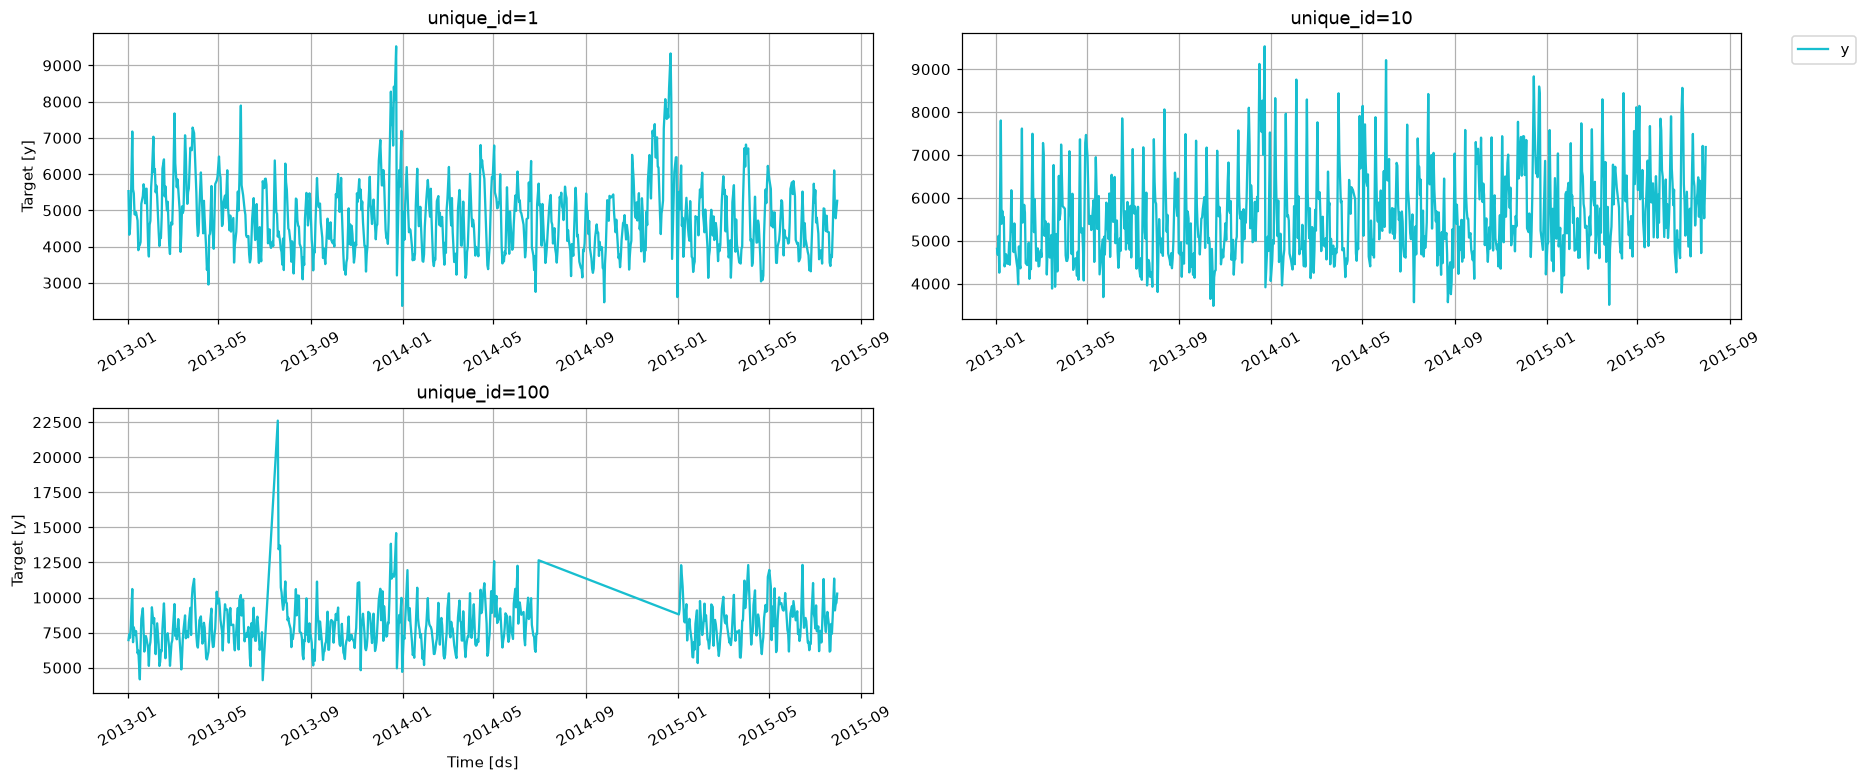

In [14]:
# Приводим к длинному формату. Оставим только открытые дни:
# ноль в закрытый день не несёт информации о спросе и портит метрики.
rossmann_long = (
    rossmann_train.loc[rossmann_train["Open"] == 1, ["Store", "Date", "Sales"]]
    .rename(columns={"Store": "unique_id", "Date": "ds", "Sales": "y"})
    .astype({"unique_id": "str"})
    .sort_values(["unique_id", "ds"], ignore_index=True)
)

describe_long(rossmann_long, "Rossmann (только открытые дни)")
plot_series(rossmann_long, max_ids=3, plot_random=False, engine="matplotlib")

In [15]:
# store.csv — статические признаки: они не меняются во времени.
# В терминологии прогнозирования это "static exogenous features".
print("store.csv:", rossmann_store.shape)
print("типы магазинов:", rossmann_store["StoreType"].value_counts().to_dict())
rossmann_store.head()

store.csv: (1115, 10)
типы магазинов: {'a': 602, 'd': 348, 'c': 148, 'b': 17}


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 2.4. Другие соревнования по временным рядам на Kaggle

Rossmann — далеко не единственное. Ниже — то, что стоит посмотреть, сгруппированное по типу
задачи. Соревнования, ставшие классикой, отмечены ⭐.

### Ритейл и спрос

| Соревнование | Чем интересно |
|---|---|
| ⭐ [M5 Forecasting — Accuracy](https://www.kaggle.com/c/m5-forecasting-accuracy) | 42 840 рядов Walmart, иерархия товар→отдел→магазин→штат |
| ⭐ [M5 Forecasting — Uncertainty](https://www.kaggle.com/c/m5-forecasting-uncertainty) | то же, но прогнозируются **квантили**, а не среднее |
| [Store Sales — Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting) | учебное соревнование «навсегда», лучшая точка входа |
| [Corporación Favorita Grocery](https://www.kaggle.com/c/favorita-grocery-sales-forecasting) | эквадорский ритейл, промо и цены на нефть как признак |
| [Walmart Recruiting — Store Sales](https://www.kaggle.com/c/walmart-recruiting-store-sales-forecasting) | классика 2014 года, праздничные недели с повышенным весом |
| [Predict Future Sales](https://www.kaggle.com/c/competitive-data-science-predict-future-sales) | 1С-данные, много товаров с нулевыми продажами |
| [Rohlik Sales Forecasting](https://www.kaggle.com/competitions/rohlik-sales-forecasting-challenge-v2) | онлайн-ритейл продуктов, свежее соревнование |

### Веб, реклама, финансы

| Соревнование | Чем интересно |
|---|---|
| ⭐ [Web Traffic Time Series](https://www.kaggle.com/c/web-traffic-time-series-forecasting) | 145 тыс. рядов посещаемости Википедии, много шума и нулей |
| ⭐ [Optiver Realized Volatility](https://www.kaggle.com/c/optiver-realized-volatility-prediction) | прогноз волатильности по тиковым данным биржи |
| [Jane Street Market Prediction](https://www.kaggle.com/c/jane-street-market-prediction) | высокочастотный трейдинг, анонимизированные признаки |
| [JPX Tokyo Stock Exchange](https://www.kaggle.com/competitions/jpx-tokyo-stock-exchange-prediction) | японские акции, ранжирование по доходности |
| [G-Research Crypto Forecasting](https://www.kaggle.com/competitions/g-research-crypto-forecasting) | 14 криптовалют, сильно коррелированные ряды |
| [Ubiquant Market Prediction](https://www.kaggle.com/competitions/ubiquant-market-prediction) | китайский рынок, 300 анонимных признаков |

### Энергетика, транспорт, климат

| Соревнование | Чем интересно |
|---|---|
| ⭐ [ASHRAE — Great Energy Predictor III](https://www.kaggle.com/c/ashrae-energy-prediction) | потребление зданий, 2380 счётчиков, много аномалий |
| [Enefit — Predict Energy Behavior](https://www.kaggle.com/competitions/predict-energy-behavior-of-prosumers) | солнечная генерация просьюмеров, погодные признаки |
| [Recruit Restaurant Visitors](https://www.kaggle.com/c/recruit-restaurant-visitor-forecasting) | посещаемость ресторанов, брони как ранний сигнал |
| [NYC Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration) | пространственно-временные данные |
| [Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption) | датасет (не соревнование): 10 лет почасового потребления PJM |

### Здравоохранение и эпидемиология

| Соревнование | Чем интересно |
|---|---|
| [COVID19 Global Forecasting](https://www.kaggle.com/c/covid19-global-forecasting-week-5) | экспоненциальный рост, данные обновлялись на ходу |
| [Child Mind Institute — Sleep States](https://www.kaggle.com/competitions/child-mind-institute-detect-sleep-states) | детекция событий в длинных рядах акселерометра |

🔍 **Совет.** На Kaggle самое ценное — не данные, а **публичные ноутбуки** во вкладке *Code*
и обсуждения в *Discussion*. По Rossmann там разобраны и feature engineering для дат, и работа
с закрытыми днями; по M5 — построение иерархических прогнозов. Это готовый учебник по практике,
которого нет в книгах. Отдельно полезно читать **solution write-up** победителей: их обычно
публикуют в Discussion после закрытия соревнования.

---
# 3. M-соревнования: датасет M4

**Документация:** https://nixtlaverse.nixtla.io/datasetsforecast/m4.html

## 3.1. Что это и зачем

**M-соревнования** (M, M2, M3, M4, M5) — серия, которую с 1982 года ведёт Спирос Макридакис.
Это не просто датасеты, а **эмпирические эксперименты о природе прогнозирования**, и они не
раз меняли представления сообщества:

* **M3** (2000) — 3003 ряда. Вывод, который многим не понравился: простые методы в среднем
  не хуже сложных.
* **M4** (2018) — **100 000 рядов** разной частоты. Победил гибрид ES-RNN (статистика +
  нейросеть), но чистые нейросети проиграли простым статистическим методам. Второе место —
  у **ансамбля** статистических моделей.
* **M5** (2020) — данные Walmart, иерархия, оценка неопределённости. Победили градиентные
  бустинги (LightGBM).

Для нас M4 ценен тем, что это **самый цитируемый эталон точности**. Если метод не бьёт на M4
простые бейзлайны — вопросы будут к методу.

## 3.2. Структура M4

100 000 рядов разбиты на 6 групп по частоте. У каждой группы **свой канонический горизонт** и
своя сезонность — их нельзя выбирать произвольно, иначе результат несопоставим:

| Группа | Рядов | Горизонт | Сезонность |
|---|---|---|---|
| Yearly | 23 000 | 6 | 1 |
| Quarterly | 24 000 | 8 | 4 |
| Monthly | 48 000 | 18 | 12 |
| Weekly | 359 | 13 | 1 |
| Daily | 4 227 | 14 | 1 |
| Hourly | 414 | 48 | 24 |

Ряды приходят из шести доменов: микро, макро, финансы, демография, промышленность, прочее.

## 3.3. Загрузка через `datasetsforecast`

Библиотека **`datasetsforecast`** от Nixtla — самый короткий путь к M-данным. Она скачивает
файлы, склеивает train и test и сразу отдаёт длинный формат.

In [16]:
from datasetsforecast.m4 import M4, M4Info

print("группы M4:", list(M4Info.groups))

# Метаданные группы: именно отсюда берут horizon и seasonality, а не придумывают сами.
info = M4Info["Hourly"]
print(
    f"\nHourly: рядов {info.n_ts}, горизонт {info.horizon}, "
    f"сезонность {info.seasonality}, freq '{info.freq}'"
)

# M4.load возвращает три объекта:
#   df   — сами ряды в длинном формате (train + test склеены),
#   X_df — экзогенные признаки (для M4 их нет -> None),
#   S_df — статические признаки (категория ряда).
m4_df, m4_X, m4_S = M4.load(directory=str(DATA_DIR / "m4"), group="Hourly")

print(f"\ndf:   {m4_df.shape}, колонки {m4_df.columns.tolist()}")
print(f"X_df: {m4_X}")
print(f"S_df: {m4_S.shape}")

группы M4: ['Yearly', 'Quarterly', 'Monthly', 'Weekly', 'Daily', 'Hourly', 'Other']

Hourly: рядов 414, горизонт 48, сезонность 24, freq 'H'

df:   (373372, 3), колонки ['unique_id', 'ds', 'y']
X_df: None
S_df: (414, 2)


In [17]:
print(m4_df.head())
print()
print("тип колонки ds:", m4_df["ds"].dtype)
print("значения ds:   ", m4_df["ds"].head(5).tolist())

  unique_id ds      y
0        H1  1  605.0
1        H1  2  586.0
2        H1  3  586.0
3        H1  4  559.0
4        H1  5  511.0

тип колонки ds: object
значения ds:    [1, 2, 3, 4, 5]


🔍 **`ds` — это номер наблюдения, а не дата!** Самая частая неожиданность при работе с M4.
(В `dtype` вы увидите `object`, но лежат внутри обычные целые числа 1, 2, 3, …)

Организаторы соревнования **сознательно скрыли календарные даты**: у ряда есть только
порядковый номер наблюдения. Сделано это, чтобы участники не могли подтянуть внешние данные
(погоду, праздники, курсы) и соревновались именно в качестве модели.

Что с этим делать:

* **Оставить как есть.** `statsforecast` умеет работать с целочисленным `ds` — нужно лишь
  передать `freq=1` вместо строки-частоты.
* **Сделать искусственный календарь.** Если модель или график требуют настоящих дат, можно
  назначить произвольную дату старта. Помните: реального смысла у неё нет, и признаки
  «день недели» / «месяц» на таком календаре будут фикцией.

Ниже — второй вариант, чтобы графики выглядели привычно.

--- M4 Hourly (20 рядов, искусственные даты) ---
строк всего:        14,960
рядов (unique_id):  20
длина ряда:         мин 748, медиана 748, макс 748
период:             2015-01-01 00:00:00 — 2015-02-01 03:00:00
пропусков в y:      0


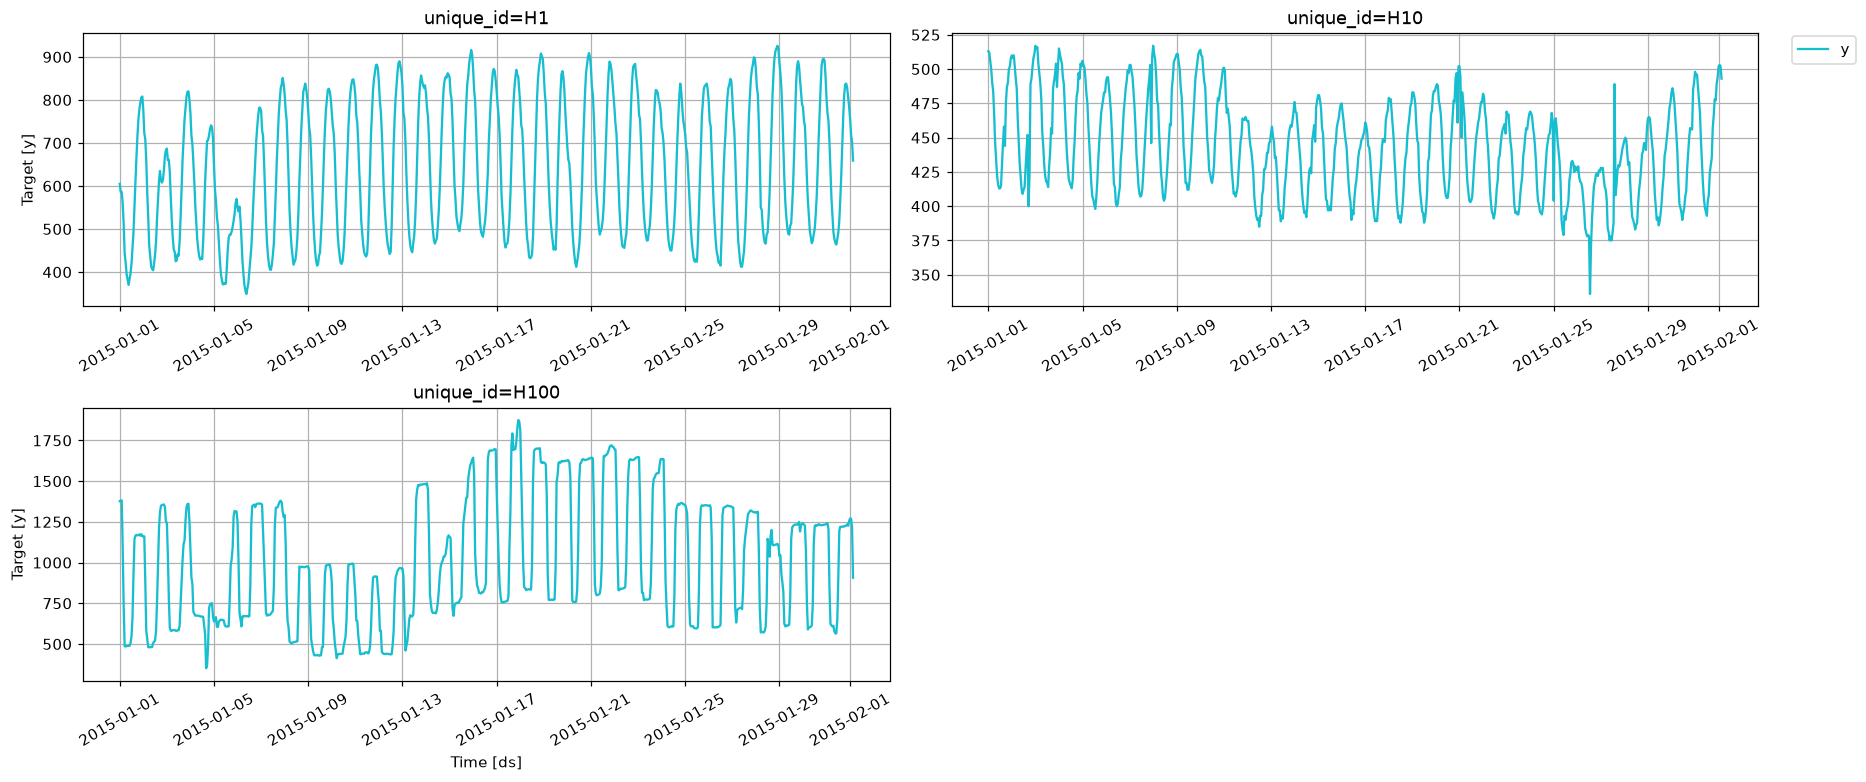

In [18]:
# Оставим 20 рядов, чтобы всё было быстро и наглядно.
subset_ids = m4_df["unique_id"].drop_duplicates().head(20)
m4_subset = m4_df[m4_df["unique_id"].isin(subset_ids)].copy()

# Целочисленный ds -> искусственный часовой календарь.
# Дата старта выбрана произвольно: в M4 реальных дат нет.
ARTIFICIAL_START = pd.Timestamp("2015-01-01")
m4_subset["ds"] = ARTIFICIAL_START + pd.to_timedelta(m4_subset["ds"] - 1, unit="h")

m4_long = m4_subset[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"], ignore_index=True)
describe_long(m4_long, "M4 Hourly (20 рядов, искусственные даты)")
plot_series(m4_long, max_ids=3, plot_random=False, engine="matplotlib")

🔍 **Что видно на графиках.** У часовых рядов M4 отчётливая **двойная сезонность**: суточный
цикл (период 24) вложен в недельный (период 168). Классические модели умеют работать только с
одним сезонным периодом — это одна из причин, почему для часовых данных берут либо
специальные модели (`MSTL`, TBATS), либо нейросети.

### Статические признаки

In [19]:
print("S_df — статические признаки (домен ряда):")
print(m4_S.head())
print("\nраспределение по категориям:")
print(m4_S["category"].value_counts())

S_df — статические признаки (домен ряда):
  unique_id  category
0        H1         5
1       H10         5
2      H100         5
3      H101         5
4      H102         5

распределение по категориям:
category
5    414
Name: count, dtype: int64


### Каноническое разбиение M4

Применим то, что разобрали в разделе 0.3: последние `horizon` точек каждого ряда — это тест.
Именно так делали организаторы, поэтому только так результаты сопоставимы с лидербордом.

In [20]:
horizon = M4Info["Hourly"].horizon
m4_test = m4_df.groupby("unique_id", observed=True).tail(horizon)
m4_train = m4_df.drop(m4_test.index)

print(f"канонический горизонт: {horizon}")
print(f"train: {m4_train.shape[0]:,} строк")
print(f"test:  {m4_test.shape[0]:,} строк  ({m4_test['unique_id'].nunique()} рядов x {horizon})")
print("\n🔍 делим по времени ВНУТРИ каждого ряда, а не случайной перестановкой строк:")
print("   иначе получим заглядывание в будущее (см. раздел 0.3)")

канонический горизонт: 48
train: 353,500 строк
test:  19,872 строк  (414 рядов x 48)

🔍 делим по времени ВНУТРИ каждого ряда, а не случайной перестановкой строк:
   иначе получим заглядывание в будущее (см. раздел 0.3)


---
# 4. Датасеты из статей: ETT, Electricity, Traffic, Weather, Exchange Rate

## 4.1. Что это и зачем

Когда в 2020–2021 годах в прогнозирование пришли трансформеры (Informer, Autoformer, FEDformer,
PatchTST, DLinear), сложился отдельный набор датасетов — **long-horizon benchmarks**. Почти
любая современная статья про нейросети для временных рядов отчитывается именно на них.

Их отличие от Monash и M4 принципиально: **мало рядов, но очень длинные и многомерные**.
Здесь не 100 000 коротких рядов, а 7–860 каналов длиной в десятки тысяч точек.

| Датасет | Что измеряется | Каналов | Точек | Частота |
|---|---|---|---|---|
| **ETTh1 / ETTh2** | нагрузка и температура масла трансформатора (Китай) | 7 | ~17 400 | 1 час |
| **ETTm1 / ETTm2** | то же, но чаще | 7 | ~69 700 | 15 мин |
| **Electricity (ECL)** | потребление 321 клиента | 321 | ~26 300 | 1 час |
| **Traffic** | загруженность 862 датчиков на шоссе (Калифорния) | 862 | ~17 500 | 1 час |
| **Weather** | 21 метеопоказатель (Германия) | 21 | ~52 700 | 10 мин |
| **Exchange Rate** | курсы валют 8 стран | 8 | ~7 500 | 1 день |

🔍 **Что значит «long-horizon».** На этих данных прогнозируют не на 12–18 шагов, как в M4, а на
**96, 192, 336 и 720** шагов вперёд. Для ETTm (15 минут) горизонт 720 — это 7.5 суток. Именно
длинный горизонт делает задачу интересной для нейросетей: короткий горизонт хорошо закрывается
простой статистикой.

## 4.2. Способ 1: `datasetsforecast` — все шесть датасетов одним вызовом

У этой группы есть готовая обёртка в `datasetsforecast`. Важная деталь: модулей **два**, и
отличаются они источником и предобработкой.

| Модуль | Что отдаёт | Источник |
|---|---|---|
| `long_horizon` | `(Y_df, X_df, S_df)`, данные всегда нормированы | S3-бакет |
| `long_horizon2` | один `DataFrame`, нормировка **отключаемая** | Dropbox |

Берём `long_horizon2`: позволяет посмотреть данные в исходном масштабе через
`normalize=False`.

> Первый запуск качает архив на 54 МБ со всеми шестью датасетами и распаковывает его в ~305 МБ.
> Дальше всё берётся с диска.

In [22]:
from datasetsforecast.long_horizon2 import LongHorizon2, LongHorizon2Info

print("доступные группы:", [name for name, _ in LongHorizon2Info])

# Метаданные: канонические размеры val/test и горизонты прямо из статей.
ett_info = LongHorizon2Info["ETTh1"]
print(f"\nETTh1: каналов {ett_info.n_ts}, точек {ett_info.n_time:,}, freq '{ett_info.freq}'")
print(f"       val_size {ett_info.val_size:,}, test_size {ett_info.test_size:,}")
print(f"       горизонты из статей: {ett_info.horizons}")

# normalize=False — хотим увидеть исходные значения, а не z-оценки.
ett_raw = LongHorizon2.load(
    directory=str(DATA_DIR / "long_horizon2"),
    group="ETTh1",
    normalize=False,
)

print(f"\nрезультат: {type(ett_raw).__name__}, {ett_raw.shape}")
print(f"колонки: {ett_raw.columns.tolist()}")
ett_raw.head()

доступные группы: ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'ECL', 'TrafficL', 'Weather']

ETTh1: каналов 7, точек 14,400, freq 'H'
       val_size 2,880, test_size 2,880
       горизонты из статей: (96, 192, 336, 720)

результат: DataFrame, (100800, 4)
колонки: ['index', 'ds', 'unique_id', 'y']


,index,ds,unique_id,y
0,0,2016-07-01 00:00:00,HUFL,5.827
1,1,2016-07-01 01:00:00,HUFL,5.693
2,2,2016-07-01 02:00:00,HUFL,5.157
3,3,2016-07-01 03:00:00,HUFL,5.090
4,4,2016-07-01 04:00:00,HUFL,5.358


### Расшифровка колонок ETT

Названия каналов выглядят как шифр, но логика простая:

| Канал | Расшифровка |
|---|---|
| `HUFL` / `HULL` | **H**igh **U**se**F**ul / **U**se**L**ess **L**oad — полезная / бесполезная нагрузка (высокая) |
| `MUFL` / `MULL` | то же для средней (**M**iddle) нагрузки |
| `LUFL` / `LULL` | то же для низкой (**L**ow) нагрузки |
| `OT` | **O**il **T**emperature — температура масла |

🔍 **`OT` — это целевая переменная.** В статьях «одномерный ETT» означает прогноз именно `OT`:
перегрев масла ведёт к аварии трансформатора, поэтому его и предсказывают. Остальные шесть
каналов — признаки. В «многомерной» постановке прогнозируют все 7 каналов сразу.

In [23]:
# Лишняя колонка index нам не нужна, а порядок приведём к стандарту Nixtla.
ett_long = ett_raw[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"], ignore_index=True)
describe_long(ett_long, "ETTh1 через datasetsforecast")
print()
print("каналы:", ett_long["unique_id"].unique().tolist())

--- ETTh1 через datasetsforecast ---
строк всего:        100,800
рядов (unique_id):  7
длина ряда:         мин 14400, медиана 14400, макс 14400
период:             2016-07-01 00:00:00 — 2018-02-20 23:00:00
пропусков в y:      0

каналы: ['HUFL', 'HULL', 'LUFL', 'LULL', 'MUFL', 'MULL', 'OT']


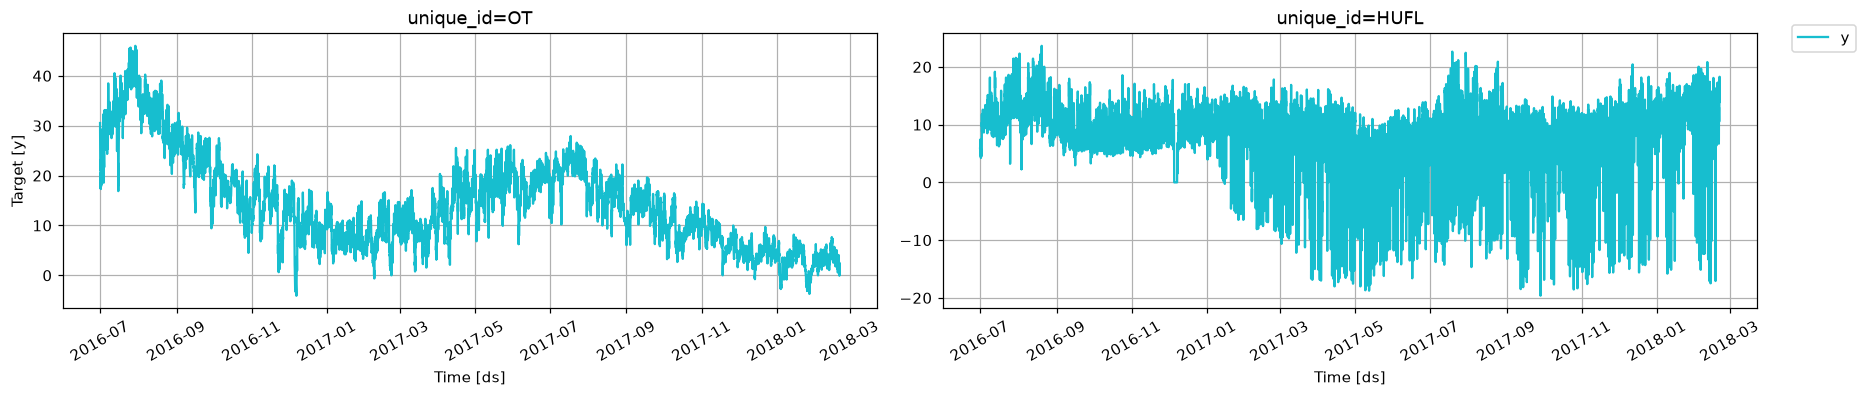

In [24]:
# Целевая переменная OT и одна из нагрузок — сравним их поведение.
plot_series(ett_long, ids=["OT", "HUFL"], engine="matplotlib")

🔍 **Сравните две панели.** `OT` — гладкий, с ярко выраженным годовым ходом (лето–зима).
`HUFL` — «мохнатый»: суточные и недельные колебания настолько сильные, что на масштабе двух
лет сливаются в полосу. Это иллюстрация того, что **одна и та же частота измерений ещё не
означает одинаковую структуру ряда**, и модели для них нужны разные.

Чтобы разглядеть суточную структуру, надо увеличить масштаб. У `plot_series` для этого есть
аргумент `max_insample_length` — показать только последние N точек.

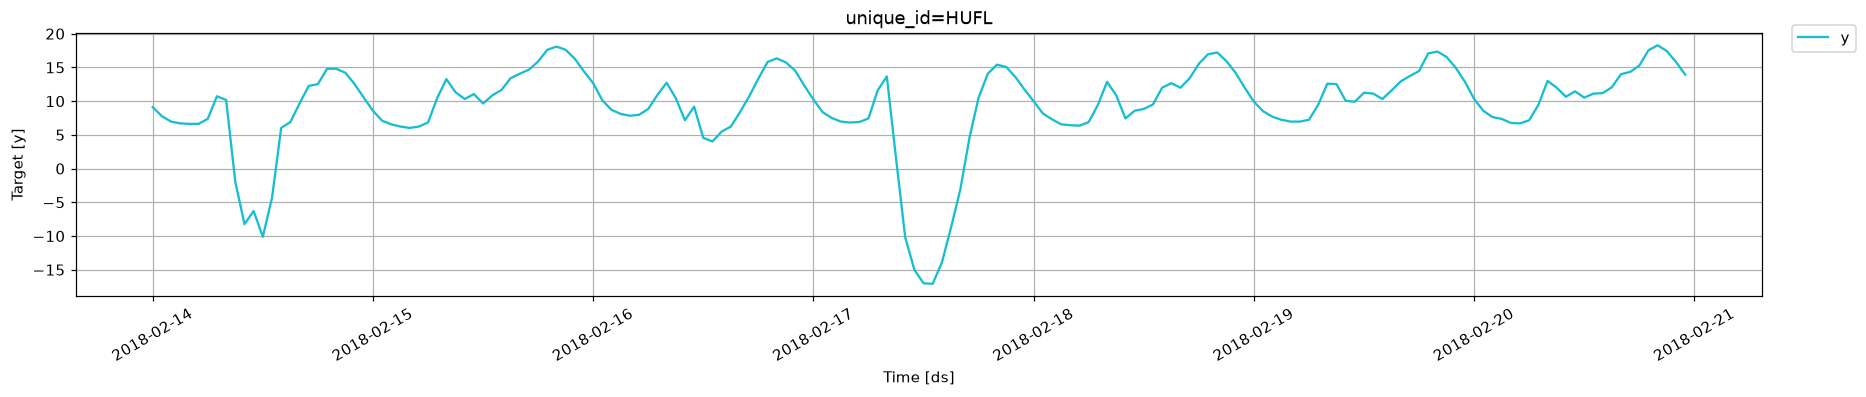

In [25]:
# Одна неделя = 168 часов вместо двух лет: вблизи видна суточная сезонность.
plot_series(ett_long, ids=["HUFL"], max_insample_length=168, engine="matplotlib")

### Остальные пять датасетов — тем же вызовом

Архив уже скачан, поэтому эти вызовы отработают с диска мгновенно:

```python
LongHorizon2.load(directory=..., group="ETTm1")     # 15-минутные данные, 57 600 точек
LongHorizon2.load(directory=..., group="ECL")       # Electricity, 321 клиент
LongHorizon2.load(directory=..., group="TrafficL")  # Traffic, 862 датчика
LongHorizon2.load(directory=..., group="Weather")   # 21 метеопоказатель
```

🔍 **Про нормировку и воспроизводимость.** По умолчанию `normalize=True`, и это не каприз
библиотеки: в статьях эти датасеты **всегда** нормируются, причём статистики (среднее и
стандартное отклонение) считаются **только по train-части** — ровно как в чек-листе из
раздела 0.3. Делят обычно 70/10/20, для ETT — 60/20/20. Если вы сравниваете свои числа с
числами из статьи, но не повторили нормировку и разбиение, числа будут несравнимы, даже если
модель та же.

## 4.3. Способ 2: исходные файлы авторов

Обёртка удобна, но полезно знать, где лежат первичные данные: обёртка может устареть, а
репозитории авторов статей живут долго.

| Датасет | Репозиторий |
|---|---|
| ETT (все варианты) | [zhouhaoyi/ETDataset](https://github.com/zhouhaoyi/ETDataset) — обычные CSV |
| Electricity, Traffic, Solar, Exchange | [laiguokun/multivariate-time-series-data](https://github.com/laiguokun/multivariate-time-series-data) — `.txt.gz` |

Формат во втором репозитории своеобразный: сжатый текст **без заголовков и без колонки с
датой** — просто матрица чисел «время × каналы». Ось времени приходится восстанавливать самим,
зная из статьи дату старта и частоту. Возьмём Exchange Rate — его в `long_horizon2` нет,
так что это ещё и способ добрать недостающий датасет.

In [26]:
LSTNET_BASE = "https://raw.githubusercontent.com/laiguokun/multivariate-time-series-data/master"
exchange_path = download(
    f"{LSTNET_BASE}/exchange_rate/exchange_rate.txt.gz",
    "exchange_rate.txt.gz",
    subdir="long_horizon",
)

# Файл сжат gzip; pandas умеет читать это сам, но покажем структуру явно.
with gzip.open(exchange_path, "rt") as f:
    first_line = f.readline()
print("первая строка файла:", first_line[:110], "...")
print("=> ни заголовков, ни дат: только числа через запятую")

exchange_wide = pd.read_csv(exchange_path, header=None)
print("\nформа матрицы:", exchange_wide.shape, "(наблюдений x каналов)")

уже скачано: data/long_horizon/exchange_rate.txt.gz  (0.18 МБ)
первая строка файла: 0.785500,1.611000,0.861698,0.634196,0.211242,0.006838,0.593000,0.525486
 ...
=> ни заголовков, ни дат: только числа через запятую

форма матрицы: (7588, 8) (наблюдений x каналов)


In [27]:
# Восстанавливаем ось времени. Из статьи известно: дневные данные с 1990-01-01.
COUNTRIES = [
    "Австралия",
    "Великобритания",
    "Канада",
    "Швейцария",
    "Китай",
    "Япония",
    "Новая Зеландия",
    "Сингапур",
]
exchange_wide.columns = COUNTRIES
exchange_wide.index = pd.date_range("1990-01-01", periods=len(exchange_wide), freq="D")
exchange_wide.index.name = "ds"

print(exchange_wide.head())

# melt "расплавляет" широкий формат в длинный.
exchange_long = (
    exchange_wide.reset_index()
    .melt(id_vars="ds", var_name="unique_id", value_name="y")[["unique_id", "ds", "y"]]
    .sort_values(["unique_id", "ds"], ignore_index=True)
)
describe_long(exchange_long, "Exchange Rate")

            Австралия  Великобритания    Канада  Швейцария     Китай  \
ds                                                                     
1990-01-01     0.7855          1.6110  0.861698   0.634196  0.211242   
1990-01-02     0.7818          1.6100  0.861104   0.633513  0.211242   
1990-01-03     0.7867          1.6293  0.861030   0.648508  0.211242   
1990-01-04     0.7860          1.6370  0.862069   0.650618  0.211242   
1990-01-05     0.7849          1.6530  0.861995   0.656254  0.211242   

              Япония  Новая Зеландия  Сингапур  
ds                                              
1990-01-01  0.006838          0.5930  0.525486  
1990-01-02  0.006863          0.5940  0.523972  
1990-01-03  0.006975          0.5973  0.526316  
1990-01-04  0.006953          0.5970  0.523834  
1990-01-05  0.006940          0.5985  0.527426  
--- Exchange Rate ---
строк всего:        60,704
рядов (unique_id):  8
длина ряда:         мин 7588, медиана 7588, макс 7588
период:             1990-01

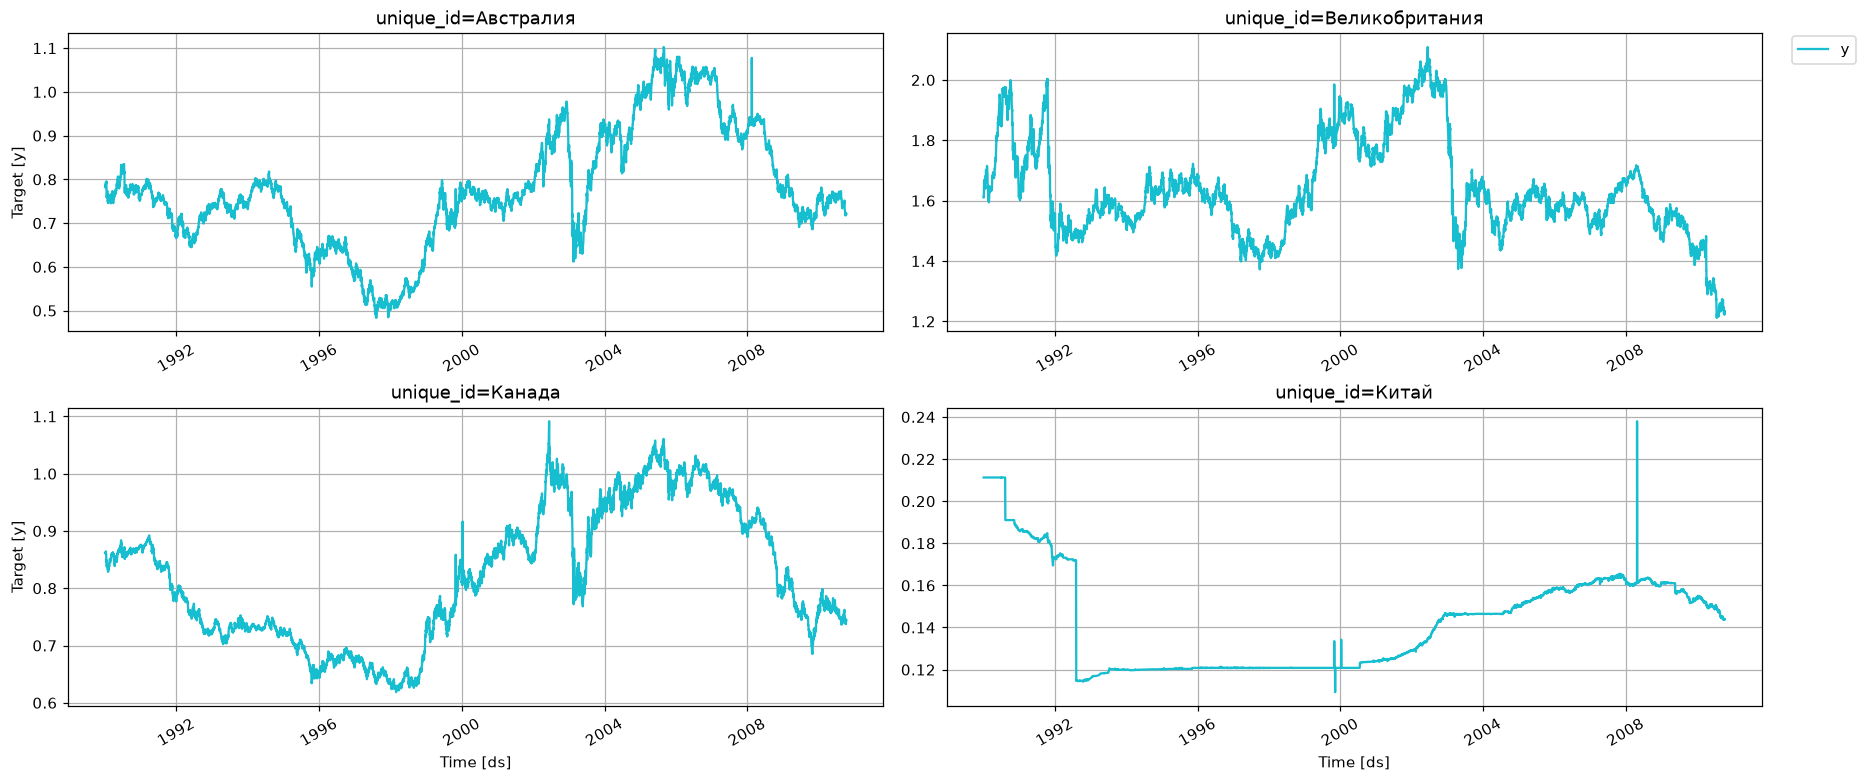

In [28]:
plot_series(exchange_long, max_ids=4, plot_random=False, engine="matplotlib")

🔍 **У курсов валют нет сезонности** — только тренды и случайные блуждания. Такие ряды очень
плохо прогнозируются: часто наивный прогноз «как вчера» оказывается лучше сложных моделей.
Это полезное отрезвляющее наблюдение: сложность модели не гарантирует качества, всё зависит
от того, есть ли в данных структура, которую вообще можно выучить.

---
# 5. LOTSA — Large-scale Open Time Series Archive

**Ссылка:** https://huggingface.co/datasets/Salesforce/lotsa_data

## 5.1. Что это и зачем

**LOTSA** — самый новый и самый крупный из наших источников. Его собрала команда Salesforce в
2024 году для обучения модели **MOIRAI** — «foundation-модели» для временных рядов.

Идея foundation-моделей пришла из NLP: вместо того чтобы учить отдельную модель на каждом
ряде, обучим одну огромную модель на **всех данных мира сразу**, а потом будем применять её к
новым рядам **без обучения** (zero-shot). Для этого нужен корпус беспрецедентного размера —
им и стала LOTSA:

* **~27 миллиардов** наблюдений,
* **170+ датасетов** в 9 доменах (энергетика, транспорт, климат, продажи, облачные сервисы,
  здравоохранение, финансы, веб, природа),
* частоты от секунд до лет.

| Плюсы | Минусы |
|---|---|
| Гигантский масштаб и разнообразие | целиком это **терабайты** — качать нельзя |
| Всё в одном формате (Arrow) | нет канонического train/test: это корпус для обучения |
| Удобная работа через `datasets` | много датасетов пересекается с Monash/LTSF |

🔍 **Главная опасность LOTSA — утечка через предобучение.** Если вы тестируете
foundation-модель, обученную на LOTSA, на датасете из Monash — велика вероятность, что этот
датасет **уже был в обучающей выборке**. Тогда «zero-shot качество» окажется фикцией. Прежде
чем заявлять zero-shot, проверьте по списку конфигураций, нет ли там ваших тестовых данных.

## 5.2. Как загружать: только по частям

LOTSA лежит на **Hugging Face Hub** и разбита на **конфигурации** (`config`) — по одной
на каждый входящий датасет.

🔍 **Не запускайте `load_dataset("Salesforce/lotsa_data")` без второго аргумента** — это
конфигурация `default`, то есть все 170 датасетов и терабайты трафика.

In [29]:
# 🔍 Настройки Hugging Face задаём ДО первого импорта datasets.
# Библиотека считывает эти переменные один раз, в момент импорта: если выставить их
# позже, они уже не подействуют, и кэш уйдёт в домашний каталог.
os.environ["HF_HOME"] = str((DATA_DIR / "hf").resolve())

# Xet — новый протокол передачи файлов Hugging Face. Он быстрее, но в некоторых
# окружениях падает с "Xet Runtime Error". Эта переменная возвращает обычный HTTPS.
os.environ["HF_HUB_DISABLE_XET"] = "1"

from datasets import get_dataset_config_names, load_dataset

configs = get_dataset_config_names("Salesforce/lotsa_data")
print(f"конфигураций в LOTSA: {len(configs)}")
print("\nпримеры (первые 20):")
for name in configs[:20]:
    print("  ", name)

'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1006)' thrown while requesting HEAD https://huggingface.co/datasets/Salesforce/lotsa_data/resolve/8191fd29eb5cf906ec55effca44d8059888b615d/lotsa_data.py
Retrying in 1s [Retry 1/5].
'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1006)' thrown while requesting HEAD https://huggingface.co/datasets/Salesforce/lotsa_data/resolve/8191fd29eb5cf906ec55effca44d8059888b615d/lotsa_data.py
Retrying in 2s [Retry 2/5].

KeyboardInterrupt



INFO:httpx:HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=Salesforce/lotsa_data "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/Salesforce/lotsa_data/tree/8191fd29eb5cf906ec55effca44d8059888b615d?recursive=true&expand=false "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/Salesforce/lotsa_data/tree/8191fd29eb5cf906ec55effca44d8059888b615d?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSmpiV2x3Tmw4eE9EYzFMMlJoZEdFdE1EQXdOVE10YjJZdE1EQXdPVFl1WVhKeWIzY2lMQ0owY21WbFgyOXBaQ0k2SWpWaFlUZ3lZV0V6WXpRM1pEY3dOall5Wm1Kall6UmxaR05rTVdaa1pqUTNabU5qTjJSaFl6TWlmUT09OjEwMDA%3D "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/Salesforce/lotsa_data/tree/8191fd29eb5cf906ec55effca44d8059888b615d?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSmpiV2x3Tmw4eE9USTFMMlJoZEdFdE1EQXdOek10YjJZdE1EQXdPVFl1WVhKeWIzY2lMQ0owY21WbFgyOXBaQ0k2SWpWaFlUZ3lZV0V6WXpRM1pEY3dOall5Wm1Kall6UmxaR05rTVdaa1pqUTNabU5qTjJSaFl6TWlmUT09OjIwMDA%3D "HTTP/1.1 200 OK"


...

INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/Salesforce/lotsa_data/tree/8191fd29eb5cf906ec55effca44d8059888b615d?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSmxjbUUxWHpJd01ESXZaR0YwWVMwd01EQXhOeTF2Wmkwd01EQTVOaTVoY25KdmR5SXNJblJ5WldWZmIybGtJam9pTldGaE9ESmhZVE5qTkRka056QTJOakptWW1Oak5HVmtZMlF4Wm1SbU5EZG1ZMk0zWkdGak15Sjk6NTAwMA%3D%3D "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/Salesforce/lotsa_data/tree/8191fd29eb5cf906ec55effca44d8059888b615d?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSmxjbUUxWHpJd01USXZaR0YwWVMwd01EQXpOeTF2Wmkwd01EQTVOaTVoY25KdmR5SXNJblJ5WldWZmIybGtJam9pTldGaE9ESmhZVE5qTkRka056QTJOakptWW1Oak5HVmtZMlF4Wm1SbU5EZG1ZMk0zWkdGak15Sjk6NjAwMA%3D%3D "HTTP/1.1 200 OK"


Resolving data files:   0%|          | 0/6388 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/lotsa_data/resolve/8191fd29eb5cf906ec55effca44d8059888b615d/dataset_infos.json "HTTP/1.1 404 Not Found"


конфигураций в LOTSA: 174

примеры (первые 20):
   default
   BEIJING_SUBWAY_30MIN
   HZMETRO
   LOOP_SEATTLE
   LOS_LOOP
   M_DENSE
   PEMS03
   PEMS04
   PEMS07
   PEMS08
   PEMS_BAY
   Q-TRAFFIC
   SHMETRO
   SZ_TAXI
   alibaba_cluster_trace_2018
   australian_electricity_demand
   azure_vm_traces_2017
   bdg-2_bear
   bdg-2_fox
   bdg-2_panther


In [26]:
# Берём "weather" — одну из самых компактных конфигураций (~3000 рядов).
# split="train" — в LOTSA всё лежит в единственном сплите: это корпус для обучения,
# а не бенчмарк с готовым тестом.
lotsa_weather = load_dataset("Salesforce/lotsa_data", "weather", split="train")

print(lotsa_weather)
print("\nсхема данных:")
for field, dtype in lotsa_weather.features.items():
    print(f"  {field:10s} {dtype}")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/lotsa_data/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/Salesforce/lotsa_data/8191fd29eb5cf906ec55effca44d8059888b615d/README.md "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/lotsa_data/resolve/8191fd29eb5cf906ec55effca44d8059888b615d/lotsa_data.py "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/Salesforce/lotsa_data/Salesforce/lotsa_data.py "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/lotsa_data/resolve/8191fd29eb5cf906ec55effca44d8059888b615d/.huggingface.yaml "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=Salesforce/lotsa_data "HTTP/1.1 200 OK"


Resolving data files:   0%|          | 0/6388 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/lotsa_data/resolve/8191fd29eb5cf906ec55effca44d8059888b615d/dataset_infos.json "HTTP/1.1 404 Not Found"


Dataset({
    features: ['item_id', 'start', 'freq', 'target'],
    num_rows: 3010
})

схема данных:
  item_id    Value('string')
  start      Value('timestamp[s]')
  freq       Value('string')
  target     List(Value('float32'))


INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/lotsa_data/resolve/8191fd29eb5cf906ec55effca44d8059888b615d/.huggingface.yaml "HTTP/1.1 404 Not Found"


INFO:httpx:HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=Salesforce/lotsa_data "HTTP/1.1 200 OK"


Resolving data files:   0%|          | 0/6388 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/lotsa_data/resolve/8191fd29eb5cf906ec55effca44d8059888b615d/dataset_infos.json "HTTP/1.1 404 Not Found"


Dataset({
    features: ['item_id', 'start', 'freq', 'target'],
    num_rows: 3010
})

схема данных:
  item_id    Value('string')
  start      Value('timestamp[s]')
  freq       Value('string')
  target     List(Value('float32'))


### Формат LOTSA: одна строка = целый ряд

Это тот же принцип, что у `.tsf` в Monash: хранить дату только для первой точки, а остальные
восстанавливать из частоты.

| Поле | Смысл |
|---|---|
| `item_id` | идентификатор ряда |
| `start` | timestamp первого наблюдения |
| `freq` | частота строкой (`D`, `H`, `10T`, …) |
| `target` | **массив** всех значений ряда |

Для миллиардов наблюдений это экономит очень много места. Обратная сторона — прежде чем
работать привычными средствами pandas, ряд надо «развернуть» в строки.

In [27]:
record = lotsa_weather[0]
print(f"item_id: {record['item_id']}")
print(f"start:   {record['start']}  (тип {type(record['start']).__name__})")
print(f"freq:    {record['freq']}")
print(f"target:  массив длиной {len(record['target'])}, первые 5: {record['target'][:5]}")

item_id: T1
start:   1970-01-01 00:00:00  (тип datetime)
freq:    D
target:  массив длиной 4225, первые 5: [1.6492334604263306, 1.6492334604263306, 1.6492334604263306, 1.6492334604263306, 1.6492334604263306]


--- LOTSA weather (5 рядов из 3010) ---
строк всего:        71,894
рядов (unique_id):  5
длина ряда:         мин 4225, медиана 8608, макс 40750
период:             1970-01-01 00:00:00 — 2081-07-26 00:00:00
пропусков в y:      0


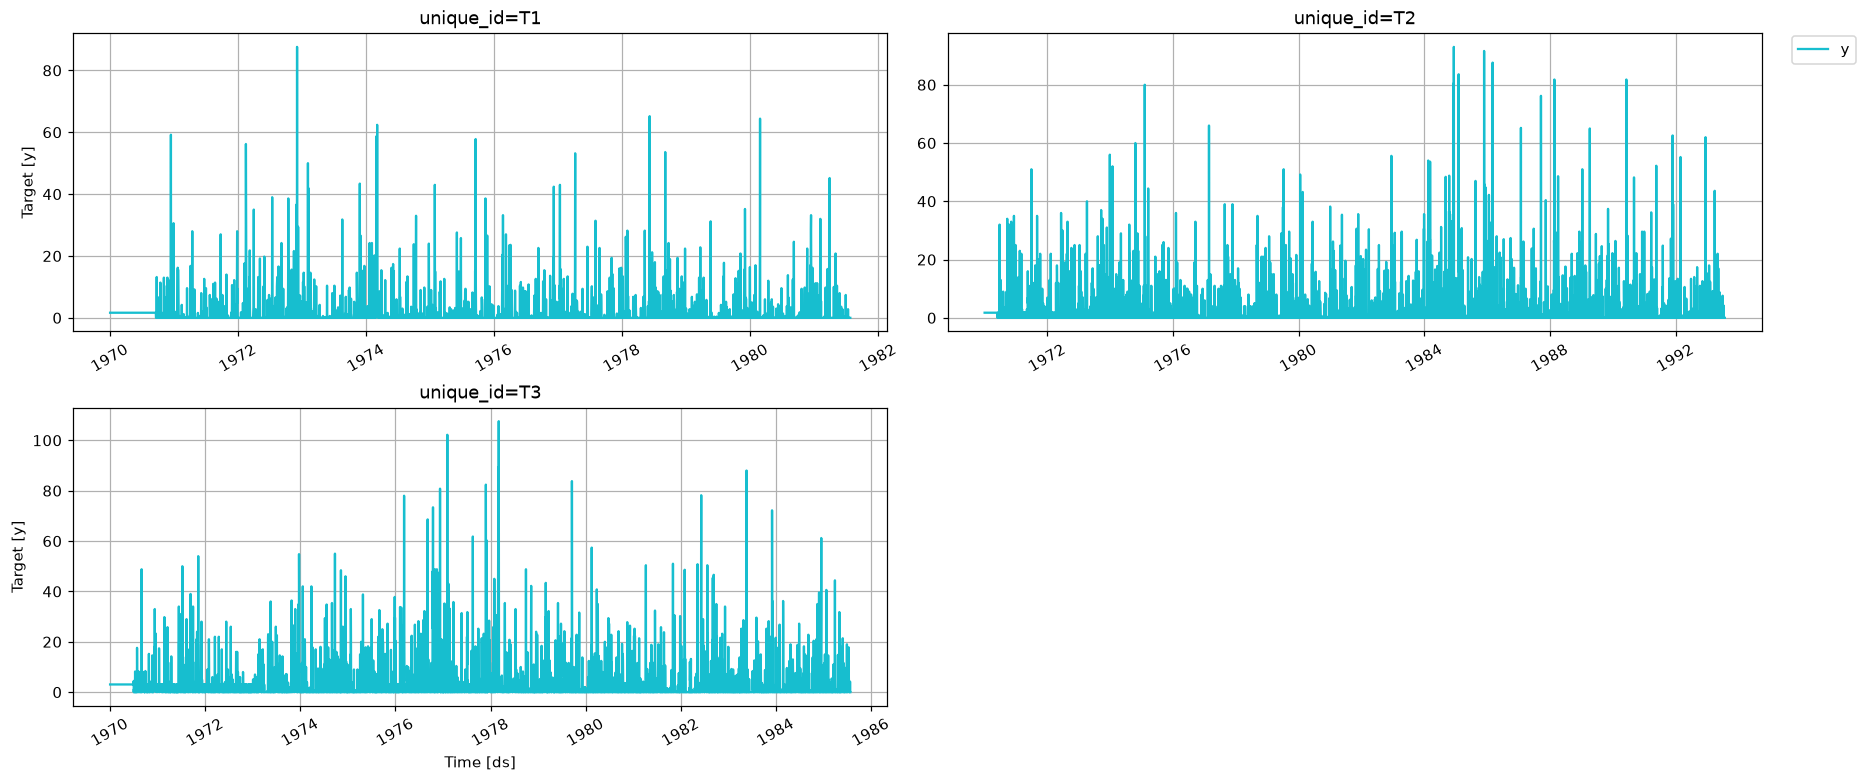

In [28]:
def lotsa_to_long(dataset, n_series: int = 5) -> pd.DataFrame:
    """Развернуть первые n_series записей LOTSA в длинный формат."""
    frames = []
    for i in range(min(n_series, len(dataset))):
        row = dataset[i]
        values = np.asarray(row["target"], dtype="float64")
        frames.append(
            pd.DataFrame(
                {
                    "unique_id": row["item_id"],
                    # start и freq берём из самой записи — они у каждого ряда свои
                    "ds": pd.date_range(row["start"], periods=len(values), freq=row["freq"]),
                    "y": values,
                }
            )
        )
    return pd.concat(frames, ignore_index=True)


lotsa_long = lotsa_to_long(lotsa_weather, n_series=5)
describe_long(lotsa_long, "LOTSA weather (5 рядов из 3010)")
plot_series(lotsa_long, max_ids=3, plot_random=False, engine="matplotlib")

🔍 **Обратите внимание на дату старта: 1970-01-01.** Это «нулевое время» Unix, то есть у этих
рядов **реальные даты неизвестны** — как и в M4, они заменены заглушкой. Для обучения
foundation-модели это не мешает (важна структура, а не календарь), но признаки вида
«день недели» на таких данных бессмысленны.

## 5.3. Потоковый режим для больших конфигураций

Конфигурация `weather` маленькая, а вот `buildings_900k` или `cmip6_*` — десятки гигабайт.
Для них есть **streaming**: данные читаются по одной записи прямо из сети, ничего не
сохраняется на диск целиком.

```python
# streaming=True возвращает IterableDataset: его нельзя индексировать [0],
# зато можно итерировать, и он не занимает места на диске.
stream = load_dataset(
    "Salesforce/lotsa_data",
    "australian_electricity_demand",
    split="train",
    streaming=True,
)

for i, row in enumerate(stream):
    print(row["item_id"], row["freq"], len(row["target"]))
    if i >= 2:
        break
```

🔍 Потоковый режим — не бесплатное ускорение: за него платят тем, что нельзя обратиться к
записи по индексу, узнать длину датасета заранее и перемешать данные обычным способом.
Для разведочного анализа удобнее скачать одну маленькую конфигурацию целиком.

---
# 7. Итоги

## 7.1. Что мы загрузили

In [29]:
loaded = {
    "Monash Hospital (sktime)": hospital_long,
    "Rossmann (Kaggle)": rossmann_long,
    "M4 Hourly": m4_long,
    "ETTh1 (datasetsforecast)": ett_long,
    "Exchange Rate": exchange_long,
    "LOTSA weather": lotsa_long,
}

summary = pd.DataFrame(
    [
        {
            "источник": name,
            "рядов": df["unique_id"].nunique(),
            "строк": len(df),
            "период": f"{df['ds'].min():%Y-%m-%d} — {df['ds'].max():%Y-%m-%d}",
        }
        for name, df in loaded.items()
    ]
).set_index("источник")
print("Все датасеты приведены к одному формату (unique_id, ds, y):\n")
summary

Все датасеты приведены к одному формату (unique_id, ds, y):



,рядов,строк,период
источник,,,
Monash Hospital (sktime),767,64428,2000-01-01 — 2006-12-01
Rossmann (Kaggle),1115,844392,2013-01-01 — 2015-07-31
M4 Hourly,20,14960,2015-01-01 — 2015-02-01
ETTh1 (datasetsforecast),7,100800,2016-07-01 — 2018-02-20
Exchange Rate,8,60704,1990-01-01 — 2010-10-10
LOTSA weather,5,71894,1970-01-01 — 2081-07-26


🔍 **Главный практический результат.** Пять источников, пять разных форматов — `.tsf`, CSV с
признаками, целочисленный индекс, матрица без заголовков, Arrow с массивами —
и все они уложились в одну и ту же таблицу из трёх колонок. Именно поэтому длинный формат
стоит выучить: он делает источники взаимозаменяемыми, и код, написанный для одного датасета,
работает с остальными без переделки.

## 7.2. Шпаргалка: какой источник для какой задачи

| Задача | Куда идти | Чем загружать |
|---|---|---|
| Сравнить свой метод с литературой | Monash + M4 | `sktime`, `datasetsforecast` |
| Научиться работать с признаками и грязью | Kaggle (Rossmann, M5) | `kagglehub` |
| Воспроизвести статью про трансформеры | ETT / Electricity / Traffic | `datasetsforecast` |
| Обучать или тестировать foundation-модель | LOTSA | `datasets` |
| Просто попробовать на маленьком примере | Monash Hospital, `nn5_weekly` | `sktime` |

## 7.3. Пять правил, которые уберегут от ошибок

1. **Никогда не перемешивайте временной ряд случайно.** Тест — это всегда «будущее».
   `train_test_split` из `sklearn` для рядов — ошибка (раздел 0.3).
2. **Соблюдайте канонический горизонт и разбиение бенчмарка.** Иначе ваши метрики нельзя
   сравнить ни с чьими.
3. **Проверяйте, доступен ли признак в момент прогноза.** `Customers` в Rossmann и
   ретроспективные пересчёты Росстата — примеры утечки, которая не видна на валидации.
4. **Кэшируйте загрузки в папку проекта.** Библиотеки по умолчанию засоряют домашний каталог,
   а данные измеряются гигабайтами.


## 7.4. Что почитать

* Godahewa et al. **Monash Time Series Forecasting Archive** (NeurIPS 2021) —
  [arxiv.org/abs/2105.06643](https://arxiv.org/abs/2105.06643)
* Makridakis et al. **The M4 Competition: 100,000 time series and 61 forecasting methods**
  (IJF 2020)
* Woo et al. **Unified Training of Universal Time Series Forecasting Transformers** (MOIRAI /
  LOTSA, ICML 2024) — [arxiv.org/abs/2402.02592](https://arxiv.org/abs/2402.02592)
* Zhou et al. **Informer** (AAAI 2021) — статья, из которой пошёл ETT